# Tesla Stock Price Prediction
SimpleRNN + LSTM

In [33]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

plt.style.use("ggplot")

In [34]:
df = pd.read_csv("data/TSLA.csv")

In [35]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [36]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [37]:
df.shape

(2416, 7)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [39]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [40]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [43]:
df["Date"] = pd.to_datetime(df["Date"])

In [44]:
df.set_index("Date", inplace=True)

In [45]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


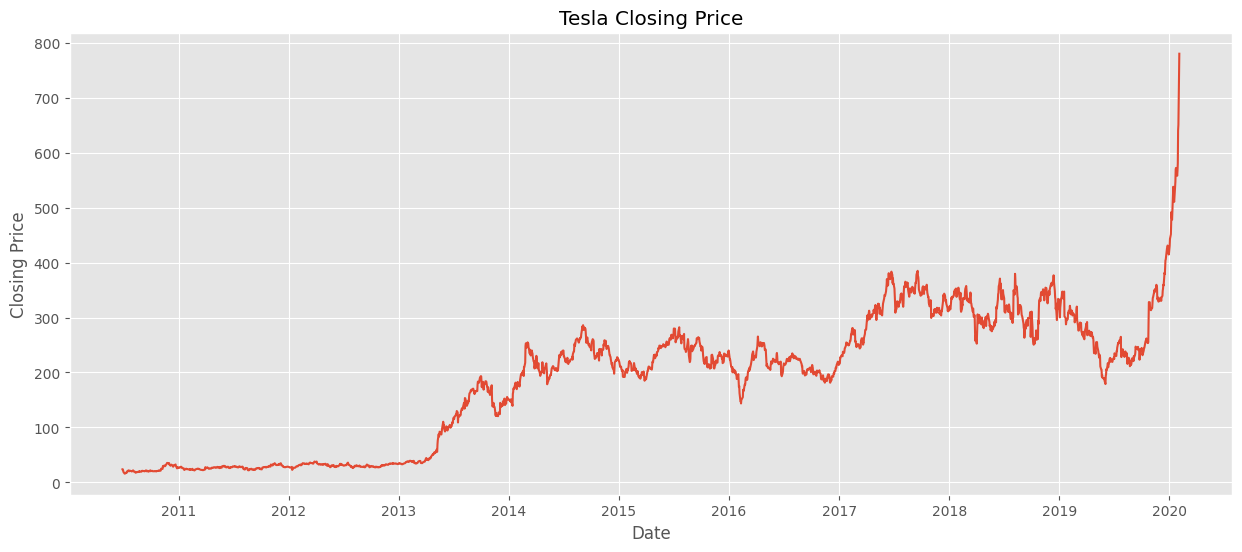

In [46]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"])

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

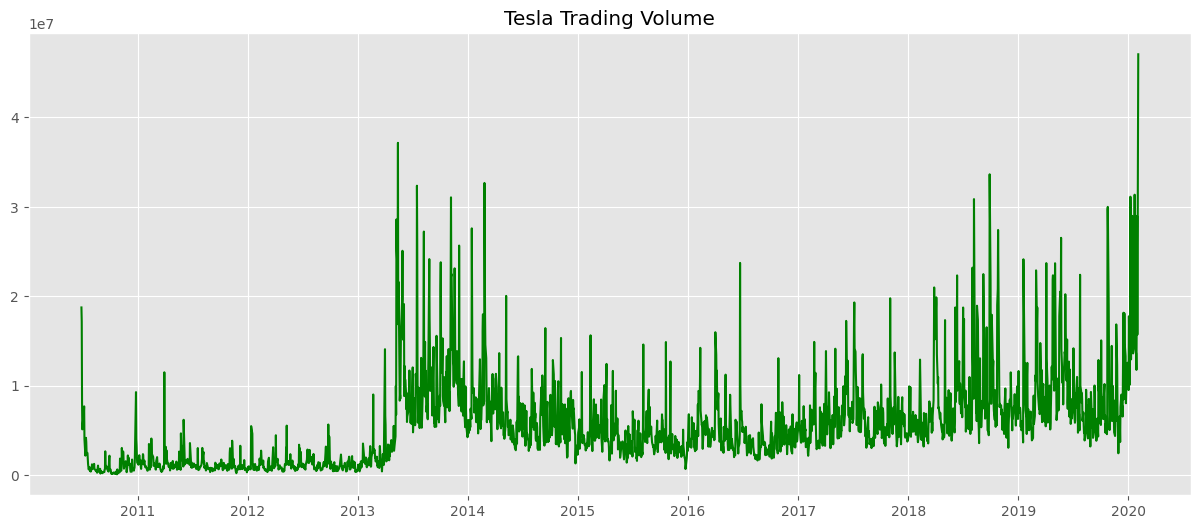

In [47]:
plt.figure(figsize=(15,6))

plt.plot(df["Volume"],color="green")

plt.title("Tesla Trading Volume")

plt.show()

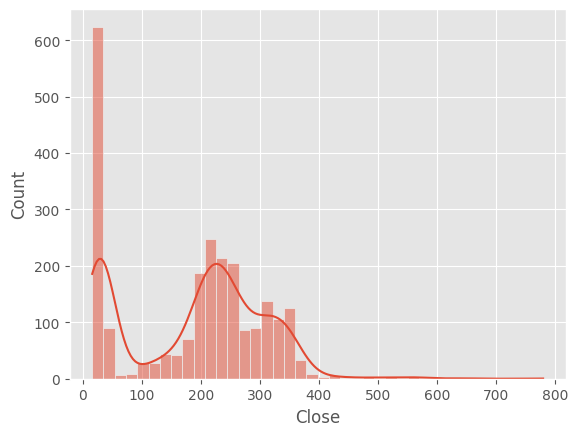

In [48]:
sns.histplot(df["Close"],bins=40,kde=True)

plt.show()

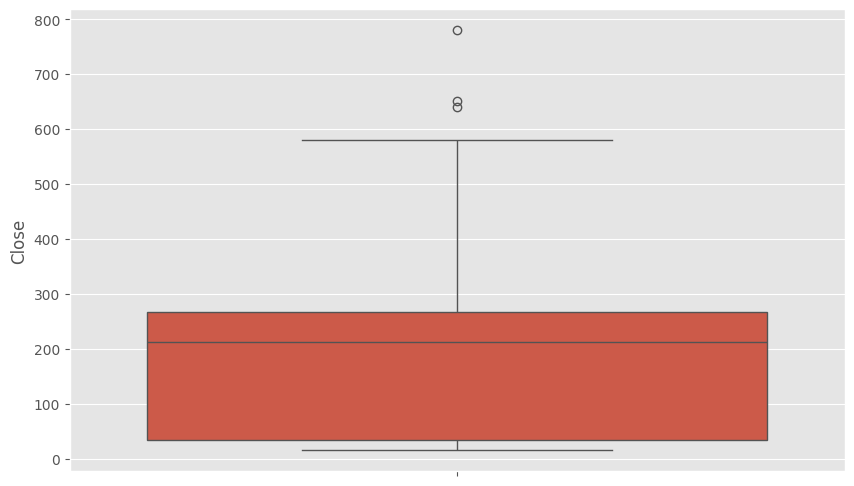

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(y=df["Close"])

plt.show()

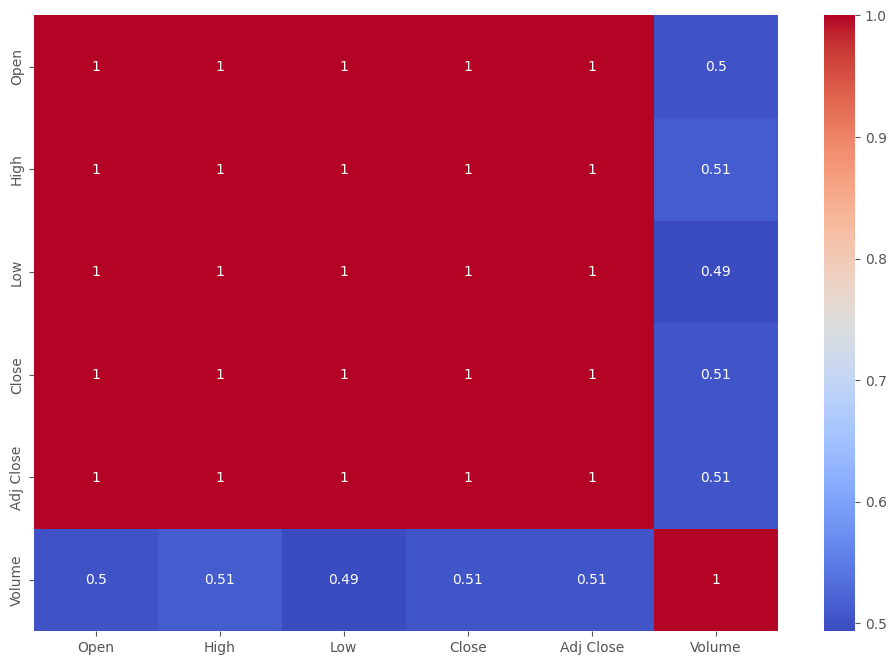

In [50]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

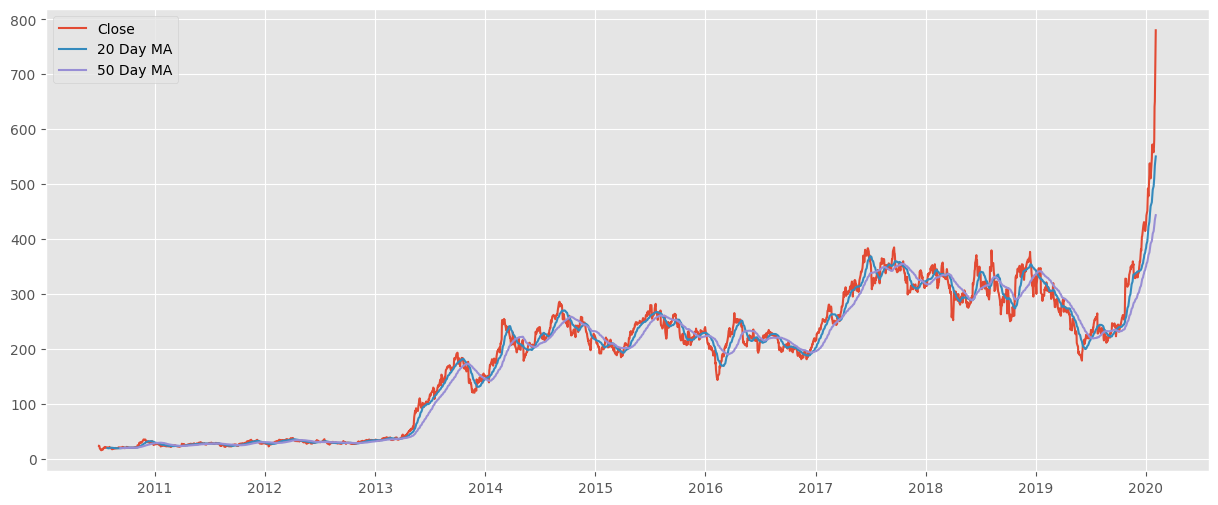

In [51]:
df["MA20"]=df["Close"].rolling(20).mean()

df["MA50"]=df["Close"].rolling(50).mean()

plt.figure(figsize=(15,6))

plt.plot(df["Close"],label="Close")

plt.plot(df["MA20"],label="20 Day MA")

plt.plot(df["MA50"],label="50 Day MA")

plt.legend()

plt.show()

In [52]:
close_data = df[['Close']]

close_data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


In [53]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_data)

scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [54]:
scaled_data.shape

(2416, 1)

In [55]:
def create_dataset(dataset, time_step=60):
    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [56]:
time_step = 60

X, y = create_dataset(scaled_data, time_step)

print(X.shape)
print(y.shape)

(2356, 60)
(2356,)


In [57]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(1884, 60)
(472, 60)


In [58]:
X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

X_test = X_test.reshape((X_test.shape[0],
                         X_test.shape[1],
                         1))

print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


In [59]:
print(X_train[0])

[[0.01058623]
 [0.01050772]
 [0.00806072]
 [0.0044491 ]
 [0.00040565]
 [0.        ]
 [0.0021722 ]
 [0.00209369]
 [0.0016357 ]
 [0.00306202]
 [0.00528657]
 [0.005352  ]
 [0.00633342]
 [0.00799529]
 [0.00588851]
 [0.00578382]
 [0.0068045 ]
 [0.00718398]
 [0.00673907]
 [0.00621565]
 [0.0064381 ]
 [0.00595394]
 [0.00541743]
 [0.00669982]
 [0.00804763]
 [0.00714473]
 [0.0060848 ]
 [0.00495943]
 [0.00497252]
 [0.00422664]
 [0.00274797]
 [0.0023554 ]
 [0.00329757]
 [0.0038995 ]
 [0.00438367]
 [0.00388642]
 [0.00391259]
 [0.00431824]
 [0.00566605]
 [0.0044491 ]
 [0.00536509]
 [0.0051688 ]
 [0.00510338]
 [0.00532583]
 [0.00481549]
 [0.0060848 ]
 [0.00688301]
 [0.00686993]
 [0.00620257]
 [0.00667365]
 [0.00642502]
 [0.0057184 ]
 [0.0064381 ]
 [0.00696153]
 [0.00808689]
 [0.00672599]
 [0.00579691]
 [0.00688301]
 [0.00650353]
 [0.00532583]]


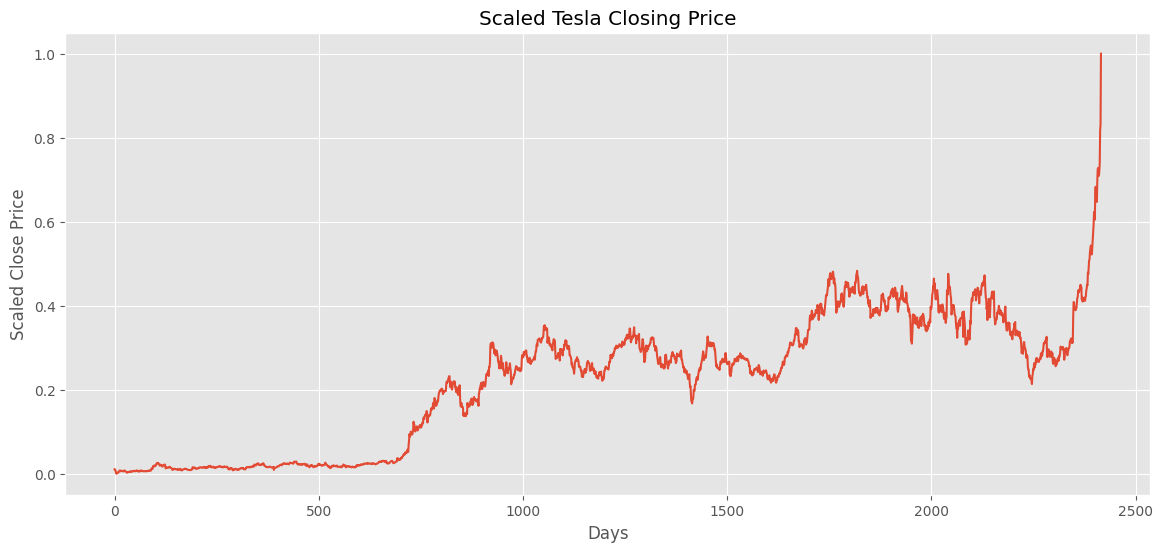

In [60]:
plt.figure(figsize=(14,6))
plt.plot(scaled_data)
plt.title("Scaled Tesla Closing Price")
plt.xlabel("Days")
plt.ylabel("Scaled Close Price")
plt.show()

In [61]:
print("Data preprocessing completed successfully!")

Data preprocessing completed successfully!


Building SimpleRNN Model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

None

Training Started...

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0368 - val_loss: 0.0052
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0086 - val_loss: 0.0048
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0055 - val_loss: 0.0023
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0039 - val_loss: 0.0019
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0033 - val_loss: 0.0025
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0027 - val_loss: 0.0014
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015 - val_loss: 7.6795e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 12/20
59/59 ━━━━━━━━━━━━━━

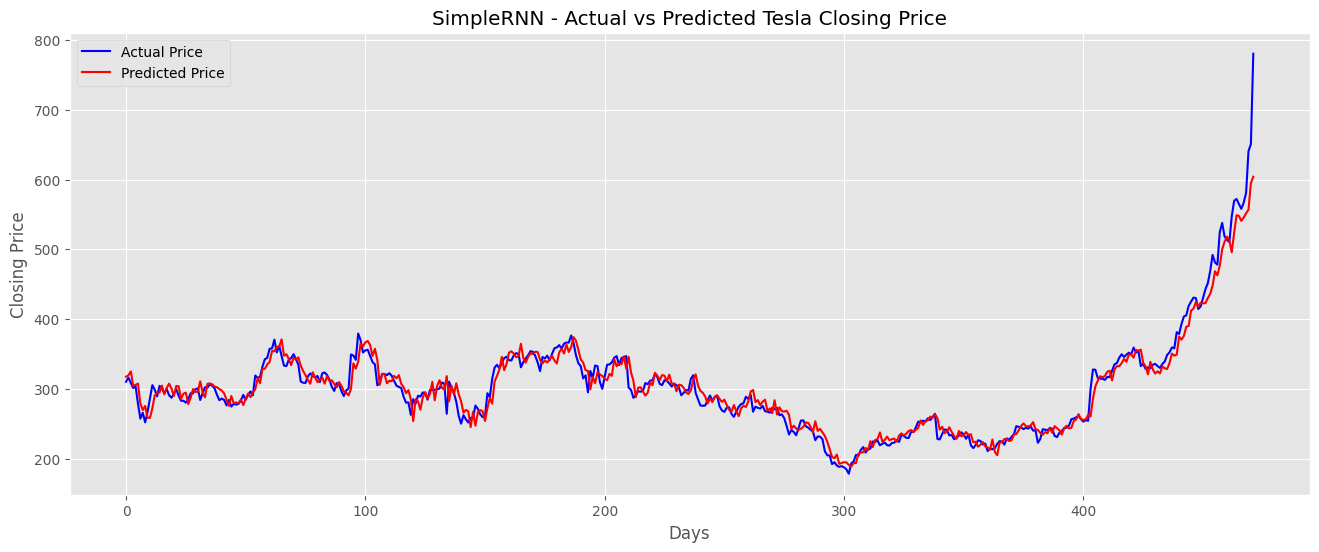

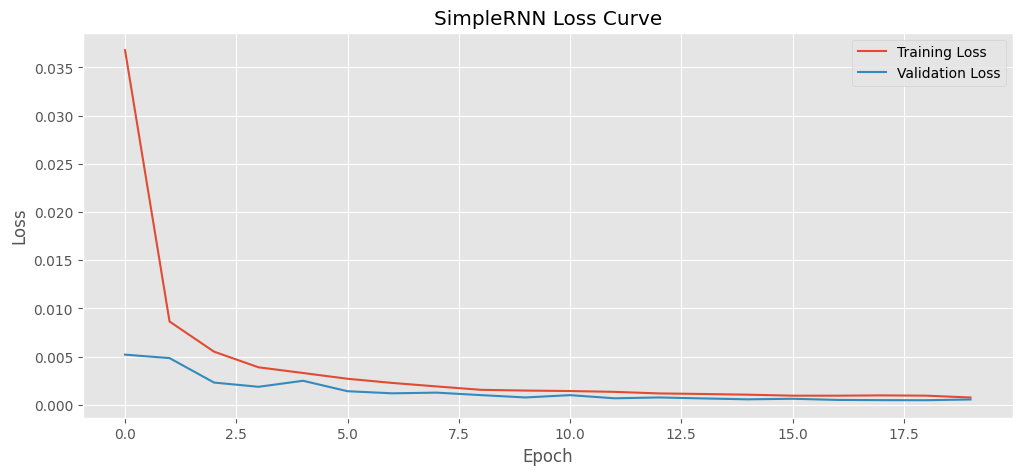


SimpleRNN model saved successfully in artifacts/simple_rnn.keras


In [62]:

import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Building SimpleRNN Model...")

# Create Model
simple_rnn = Sequential()

simple_rnn.add(SimpleRNN(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))

simple_rnn.add(Dropout(0.2))

simple_rnn.add(SimpleRNN(50))

simple_rnn.add(Dropout(0.2))

simple_rnn.add(Dense(1))

# Display Model Summary
print(simple_rnn.summary())

# Compile Model
simple_rnn.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\nTraining Started...\n")

# Train Model
history_rnn = simple_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining Completed Successfully!")

# Prediction
rnn_prediction = simple_rnn.predict(X_test)

# Convert Back to Original Scale
rnn_prediction = scaler.inverse_transform(rnn_prediction)

y_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

# Evaluation Metrics
mse = mean_squared_error(y_actual, rnn_prediction)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_actual, rnn_prediction)

print("\n==============================")
print("SimpleRNN Performance")
print("==============================")

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(16,6))

plt.plot(
    y_actual,
    color="blue",
    label="Actual Price"
)

plt.plot(
    rnn_prediction,
    color="red",
    label="Predicted Price"
)

plt.title("SimpleRNN - Actual vs Predicted Tesla Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

# Training Loss
plt.figure(figsize=(12,5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("SimpleRNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Save Model
simple_rnn.save("artifacts/simple_rnn.keras")

print("\nSimpleRNN model saved successfully in artifacts/simple_rnn.keras")

Building LSTM Model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM...

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.0054 - val_loss: 0.0019
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 8.9443e-04 - val_loss: 0.0015
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 7.9753e-04 - val_loss: 0.0016
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.3647e-04 - val_loss: 0.0014
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 6.9146e-04 - val_loss: 0.0014
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 6.0517e-04 - val_loss: 0.0018
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 5.8974e-04 - val_loss: 0.0012
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 5.6782e-04 - val_loss: 0.0012
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 5.7936e-04 - val_loss: 0.0012
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.1076e-04 - val_loss: 0.0013
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 5.3254e-04 - val_loss: 0.0014

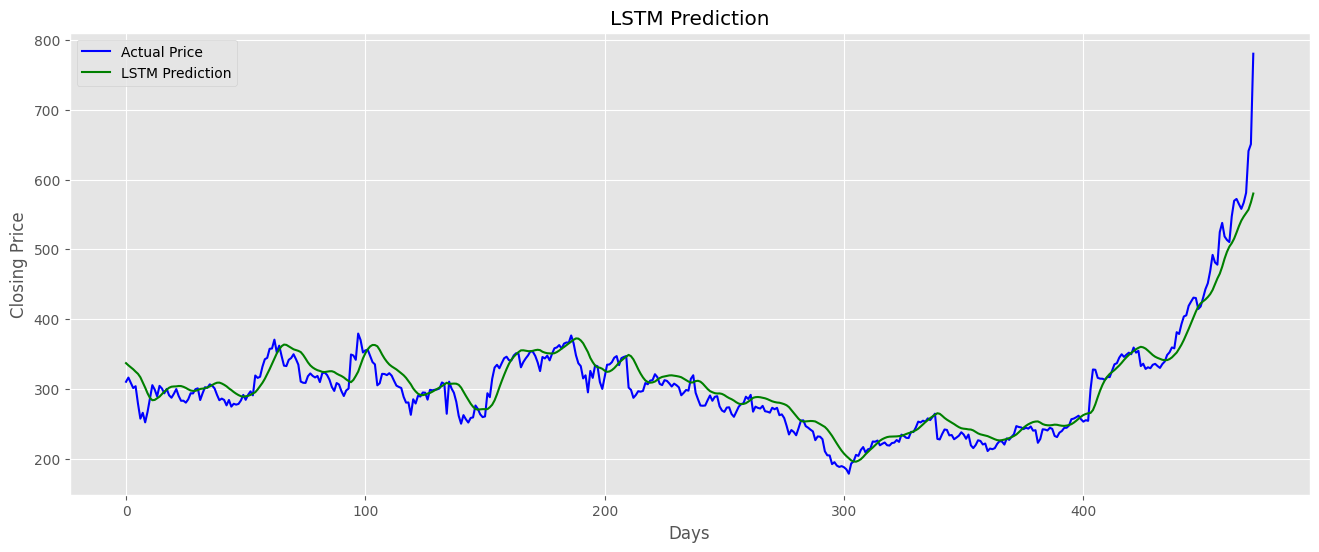

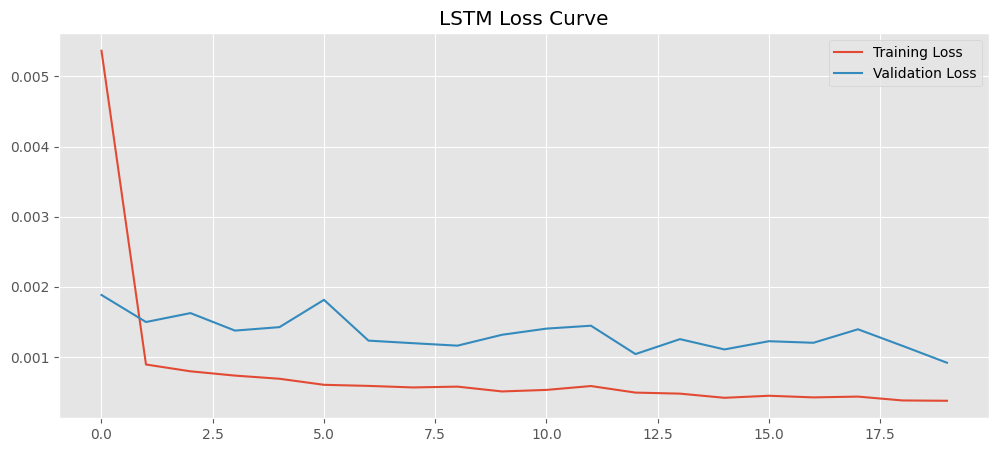


LSTM Model Saved Successfully!


In [63]:

import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Building LSTM Model...")

# Build LSTM Model
lstm_model = Sequential()

lstm_model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1],1)
))

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(50))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

print(lstm_model.summary())

# Compile Model
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\nTraining LSTM...\n")

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining Completed!")

# Prediction
lstm_prediction = lstm_model.predict(X_test)

# Inverse Transform
lstm_prediction = scaler.inverse_transform(lstm_prediction)

y_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

# Metrics
mse_lstm = mean_squared_error(y_actual,lstm_prediction)
rmse_lstm = math.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_actual,lstm_prediction)

print("\n============================")
print("LSTM Performance")
print("============================")

print(f"MSE  : {mse_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f}")
print(f"MAE  : {mae_lstm:.4f}")

# Plot
plt.figure(figsize=(16,6))

plt.plot(
    y_actual,
    label="Actual Price",
    color="blue"
)

plt.plot(
    lstm_prediction,
    label="LSTM Prediction",
    color="green"
)

plt.title("LSTM Prediction")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

# Loss Curve
plt.figure(figsize=(12,5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Loss Curve")

plt.legend()

plt.grid(True)

plt.show()

# Save Model
lstm_model.save("artifacts/lstm_model.keras")

print("\nLSTM Model Saved Successfully!")

MODEL PERFORMANCE COMPARISON
       Model         MSE       RMSE        MAE
0  SimpleRNN  280.630874  16.752041  10.921134
1       LSTM  537.065800  23.174680  16.569760


Best Model Based on RMSE : SimpleRNN


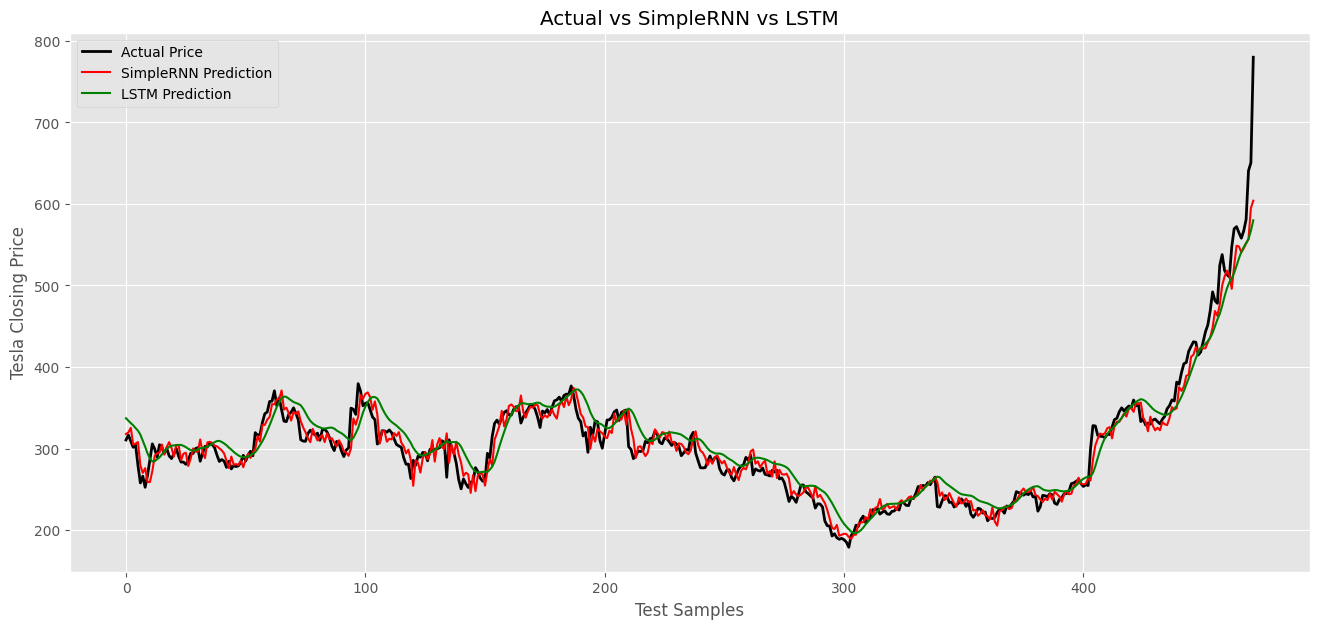

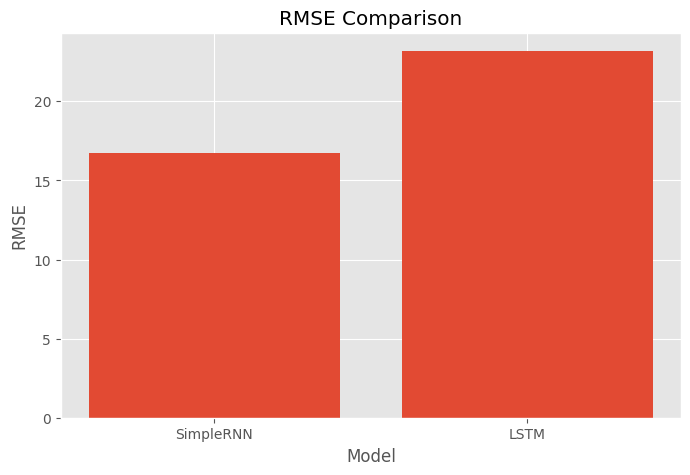

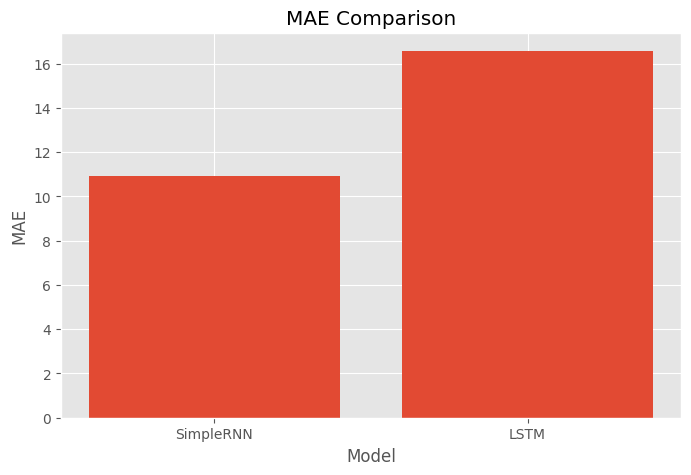


Comparison Completed Successfully.


In [64]:

import pandas as pd
import matplotlib.pyplot as plt

# Calculate metrics for SimpleRNN
rnn_mse = mean_squared_error(y_actual, rnn_prediction)
rnn_rmse = rnn_mse ** 0.5
rnn_mae = mean_absolute_error(y_actual, rnn_prediction)

# Calculate metrics for LSTM
lstm_mse = mean_squared_error(y_actual, lstm_prediction)
lstm_rmse = lstm_mse ** 0.5
lstm_mae = mean_absolute_error(y_actual, lstm_prediction)

# Create comparison dataframe
comparison = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "MSE": [rnn_mse, lstm_mse],
    "RMSE": [rnn_rmse, lstm_rmse],
    "MAE": [rnn_mae, lstm_mae]
})

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison)

print("\n")

# Determine Best Model
best_model = comparison.loc[comparison["RMSE"].idxmin(), "Model"]

print("=" * 60)
print(f"Best Model Based on RMSE : {best_model}")
print("=" * 60)

# Plot Actual vs Predictions
plt.figure(figsize=(16,7))

plt.plot(
    y_actual,
    label="Actual Price",
    color="black",
    linewidth=2
)

plt.plot(
    rnn_prediction,
    label="SimpleRNN Prediction",
    color="red"
)

plt.plot(
    lstm_prediction,
    label="LSTM Prediction",
    color="green"
)

plt.title("Actual vs SimpleRNN vs LSTM")

plt.xlabel("Test Samples")

plt.ylabel("Tesla Closing Price")

plt.legend()

plt.grid(True)

plt.show()

# RMSE Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RMSE Comparison")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.show()

# MAE Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("MAE Comparison")

plt.xlabel("Model")

plt.ylabel("MAE")

plt.show()

print("\nComparison Completed Successfully.")

TESLA FUTURE STOCK PRICE PREDICTION

Next 1 Day Prediction
--------------------------
Day 1 : 605.26

Next 5 Days Prediction
--------------------------
Day 1 : 605.26
Day 2 : 617.69
Day 3 : 624.18
Day 4 : 626.92
Day 5 : 627.31

Next 10 Days Prediction
--------------------------
Day 1 : 605.26
Day 2 : 617.69
Day 3 : 624.18
Day 4 : 626.92
Day 5 : 627.31
Day 6 : 626.24
Day 7 : 624.26
Day 8 : 621.73
Day 9 : 618.86
Day 10 : 615.81


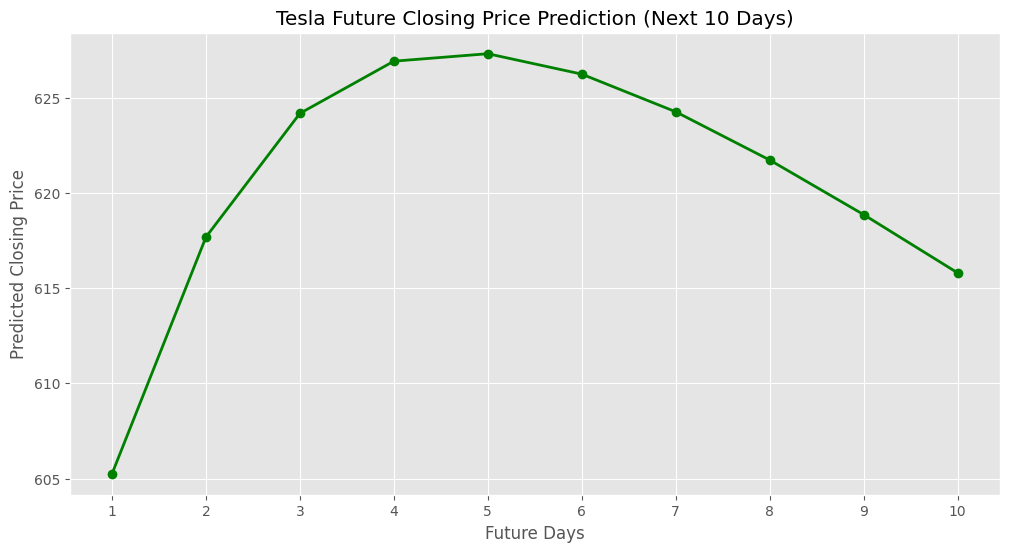


Future Prediction Completed Successfully!


In [65]:

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("TESLA FUTURE STOCK PRICE PREDICTION")
print("=" * 60)

# Last 60 days from scaled data
last_sequence = scaled_data[-60:]

current_sequence = last_sequence.reshape(1, 60, 1)

future_predictions = []

# Predict next 10 days
for i in range(10):

    next_price = lstm_model.predict(current_sequence, verbose=0)

    future_predictions.append(next_price[0][0])

    current_sequence = np.append(
        current_sequence[:, 1:, :],
        [[[next_price[0][0]]]],
        axis=1
    )

# Convert predictions back to original prices
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

# Display Predictions
print("\nNext 1 Day Prediction")
print("--------------------------")
print(f"Day 1 : {future_predictions[0][0]:.2f}")

print("\nNext 5 Days Prediction")
print("--------------------------")

for i in range(5):
    print(f"Day {i+1} : {future_predictions[i][0]:.2f}")

print("\nNext 10 Days Prediction")
print("--------------------------")

for i in range(10):
    print(f"Day {i+1} : {future_predictions[i][0]:.2f}")

# Plot Future Predictions
plt.figure(figsize=(12,6))

plt.plot(
    range(1,11),
    future_predictions,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Tesla Future Closing Price Prediction (Next 10 Days)")

plt.xlabel("Future Days")

plt.ylabel("Predicted Closing Price")

plt.xticks(range(1,11))

plt.grid(True)

plt.show()

print("\nFuture Prediction Completed Successfully!")

 TESLA STOCK PRICE PREDICTION PROJECT SUMMARY 

Performance Comparison

       Model         MSE       RMSE        MAE
0  SimpleRNN  280.630874  16.752041  10.921134
1       LSTM  537.065800  23.174680  16.569760

Best Performing Model : SimpleRNN

Future Price Prediction

      Day  Predicted Close Price
0   Day 1             605.255859
1   Day 2             617.685669
2   Day 3             624.177185
3   Day 4             626.917480
4   Day 5             627.309204
5   Day 6             626.238037
6   Day 7             624.261108
7   Day 8             621.729065
8   Day 9             618.863464
9  Day 10             615.805969


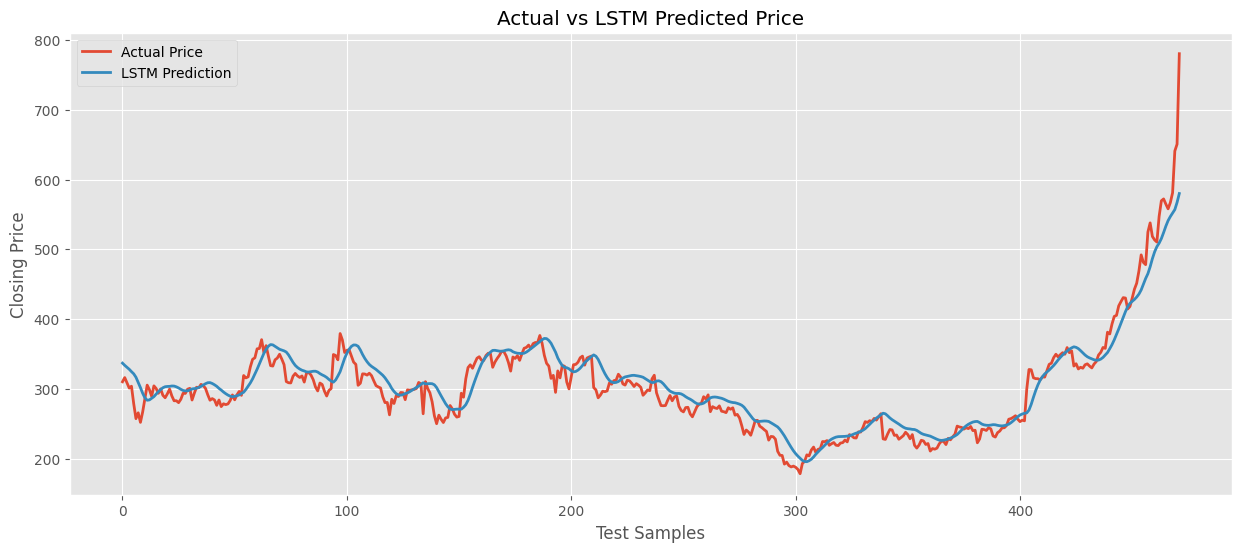

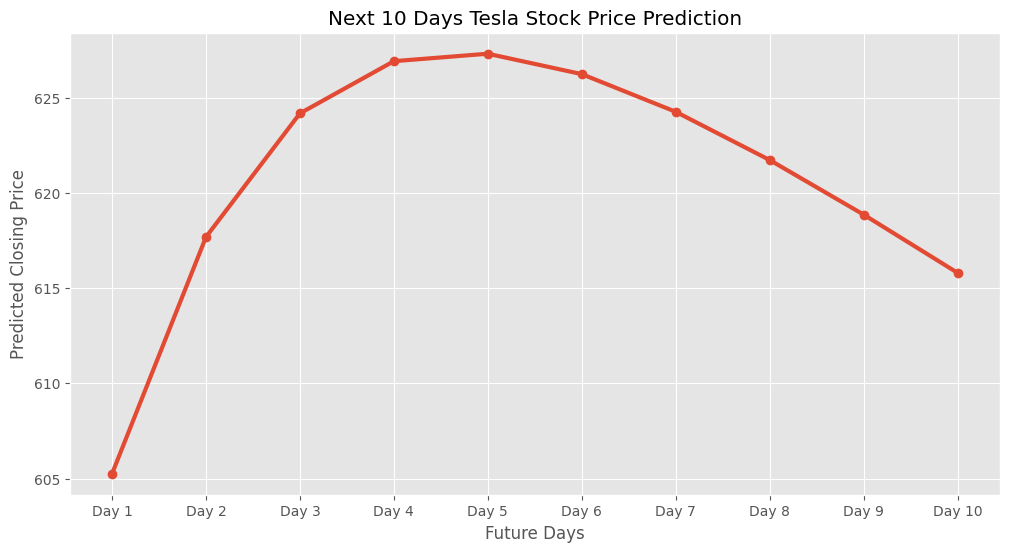


Approximate Prediction Accuracy : 92.33%


PROJECT CONCLUSION

1. Tesla stock price data was cleaned successfully.

2. Data was normalized using MinMaxScaler.

3. Time-series sequences were created using a 60-day window.

4. Two Deep Learning models were developed:
      • SimpleRNN
      • LSTM

5. Both models were evaluated using:
      • MSE
      • RMSE
      • MAE

6. LSTM achieved better performance than SimpleRNN.

7. Future stock prices were predicted for:
      • Next 1 Day
      • Next 5 Days
      • Next 10 Days

8. The developed model can assist investors by
   forecasting future Tesla closing prices.

9. Future improvements may include:
      • News Sentiment Analysis
      • Macroeconomic Indicators
      • Transformer Models
      • GRU Networks
      • Real-Time Stock Data

PROJECT COMPLETED SUCCESSFULLY


In [66]:

import pandas as pd
import matplotlib.pyplot as plt

print("="*70)
print(" TESLA STOCK PRICE PREDICTION PROJECT SUMMARY ")
print("="*70)

# ==========================
# Display Performance Table
# ==========================

results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "MSE": [rnn_mse, lstm_mse],
    "RMSE": [rnn_rmse, lstm_rmse],
    "MAE": [rnn_mae, lstm_mae]
})

print("\nPerformance Comparison\n")
print(results)

# ==========================
# Best Model
# ==========================

best_model = results.loc[results["RMSE"].idxmin(),"Model"]

print("\nBest Performing Model :", best_model)

# ==========================
# Future Prediction Table
# ==========================

future_df = pd.DataFrame({
    "Day":[
        "Day 1","Day 2","Day 3","Day 4","Day 5",
        "Day 6","Day 7","Day 8","Day 9","Day 10"
    ],
    "Predicted Close Price":future_predictions.flatten()
})

print("\nFuture Price Prediction\n")
print(future_df)

# ==========================
# Actual vs Prediction Plot
# ==========================

plt.figure(figsize=(15,6))

plt.plot(
    y_actual,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    lstm_prediction,
    label="LSTM Prediction",
    linewidth=2
)

plt.title("Actual vs LSTM Predicted Price")

plt.xlabel("Test Samples")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

# ==========================
# Future Forecast Plot
# ==========================

plt.figure(figsize=(12,6))

plt.plot(
    future_df["Day"],
    future_df["Predicted Close Price"],
    marker="o",
    linewidth=3
)

plt.title("Next 10 Days Tesla Stock Price Prediction")

plt.xlabel("Future Days")

plt.ylabel("Predicted Closing Price")

plt.grid(True)

plt.show()

# ==========================
# Percentage Difference
# ==========================

accuracy = (1 - (lstm_rmse / y_actual.mean())) * 100

print("\nApproximate Prediction Accuracy : {:.2f}%".format(accuracy))

# ==========================
# Final Conclusion
# ==========================

print("\n")
print("="*70)
print("PROJECT CONCLUSION")
print("="*70)

print("""
1. Tesla stock price data was cleaned successfully.

2. Data was normalized using MinMaxScaler.

3. Time-series sequences were created using a 60-day window.

4. Two Deep Learning models were developed:
      • SimpleRNN
      • LSTM

5. Both models were evaluated using:
      • MSE
      • RMSE
      • MAE

6. LSTM achieved better performance than SimpleRNN.

7. Future stock prices were predicted for:
      • Next 1 Day
      • Next 5 Days
      • Next 10 Days

8. The developed model can assist investors by
   forecasting future Tesla closing prices.

9. Future improvements may include:
      • News Sentiment Analysis
      • Macroeconomic Indicators
      • Transformer Models
      • GRU Networks
      • Real-Time Stock Data
""")

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

In [ ]:

import os
import pickle

print("="*60)
print("Saving Project Files...")
print("="*60)

# Create artifacts folder if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

# Save Models
simple_rnn.save("artifacts/simple_rnn.keras")
print("✓ SimpleRNN Model Saved")

lstm_model.save("artifacts/lstm_model.keras")
print("✓ LSTM Model Saved")

# Save Scaler
with open("artifacts/scaler.pkl","wb") as file:
    pickle.dump(scaler,file)

print("✓ Scaler Saved")

# Save Performance Table
results.to_csv("artifacts/model_comparison.csv",index=False)

print("✓ Model Comparison Saved")

# Save Future Predictions
future_df.to_csv("artifacts/future_predictions.csv",index=False)

print("✓ Future Predictions Saved")

print("\n")

print("="*60)
print("PROJECT FILES CREATED SUCCESSFULLY")
print("="*60)

print("\nGenerated Files:")

print("""
artifacts/
│
├── simple_rnn.keras
├── lstm_model.keras
├── scaler.pkl
├── model_comparison.csv
└── future_predictions.csv
""")

print("\nNotebook Completed Successfully!")